J23 - Analyse RH & demographique

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

HEURE 1 - Audit et nettoyage des donnees

(650, 17)
employee_id           0
age                   0
gender                0
city                  0
education             0
department            0
role                  0
years_experience      0
hire_date             0
weekly_hours          0
overtime_hours        0
remote_days           0
monthly_salary_mad    0
performance_score     0
satisfaction_score    0
contract_type         0
promoted_last_2y      0
dtype: int64
0
employee_id                      str
age                            int64
gender                           str
city                             str
education                        str
department                       str
role                             str
years_experience               int64
hire_date             datetime64[us]
weekly_hours                   int64
overtime_hours               float64
remote_days                    int64
monthly_salary_mad             int64
performance_score            float64
satisfaction_score           float64
contract_typ

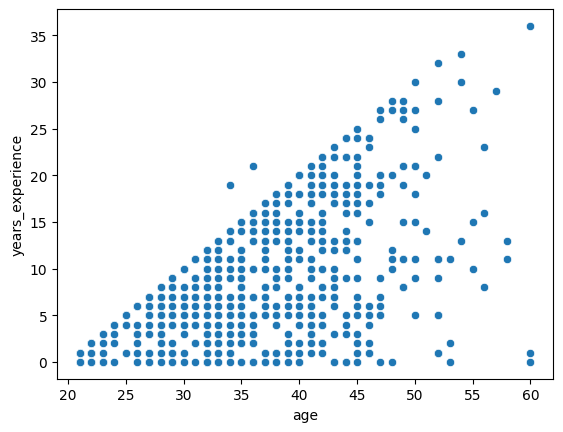

In [203]:
#1
df = pd.read_csv("J23_dataset_employes.csv")
df
#2
df.shape
df.dtypes
#3
df.isna().sum()
perc = df.isna().sum()
Valeur_Nan = (perc/ len(df)) * 100
Valeur_Nan.round(2)
#4
df[df.duplicated()]
df.duplicated().sum()
df = df.drop_duplicates().copy()
#5
df["gender"].value_counts(dropna=False)
df["city"].value_counts(dropna=False)
df["gender"].value_counts(dropna=False)
df["city"].value_counts(dropna=False)
df["department"].value_counts(dropna=False)
df["role"].value_counts(dropna=False)
df["contract_type"].value_counts(dropna=False)
df["promoted_last_2y"].value_counts(dropna=False)

#6
df["gender"] = df["gender"].str.title().str.strip()
df["city"] = df["city"].str.title().str.strip()
df["education"] = df["education"].str.title().str.strip()
df["department"] = df["department"].str.strip()
#7
df["hire_date"] = pd.to_datetime(df["hire_date"], format="mixed")
#8
sns.scatterplot(data = df, x = "age" , y = "years_experience", marker = "o")
"""On remarque dans le graphe du scatter qu'il y a deux personnes entre age 30 et 40 qui sont
au dessus de la nuage des points , c'est comme des valeurs atypiques, on consate qui ont des annees
d'experience entre 15 et 21 ce qui est different de les autres.
On ne doit pas les supprimer, on doit attendre de savoir est ce qu'il y a une ou des
autres valeurs qui influecent la relation age - annees d'experience"""
#9
df["city"] = df["city"].fillna(df["city"].mode()[0]) # valeur categorielle
df["education"]=df["education"].fillna(df["education"].mode()[0]) # valeur categorielle
df["role"] = df["role"].fillna("Inconnu")
df["performance_score"]= df["performance_score"].fillna(df["performance_score"].median()) # valeur numerique
df["satisfaction_score"]=df["satisfaction_score"].fillna(df["satisfaction_score"].median()) # valeur numerique
"""J'ai utilsier la mediane car j'ai remarquer qu'il y a des valeurs atypiques"""
#10
print(df.shape)
print(df.isna().sum())
print(df.duplicated().sum())
print(df.dtypes)

HEURE 2 - Analyse demographique et salariale

In [ ]:
#1
age_moyen = df["age"].mean()
age_moyen.round(2)
age_median = df["age"].median()
age_median
#2
N = df.groupby("department")["department"].count()
P = (N / (N.sum())) * 100
P.round(2)
#3
plus_emp = df.groupby("city")["employee_id"].count()
(plus_emp.sort_values(ascending = False)).head(3)
#4
salaire_moy = df["monthly_salary_mad"].mean()
salaire_moy.round(2)
salaire_med = df["monthly_salary_mad"].median()
salaire_med
#5
df.groupby("education").agg(effectif = ("employee_id","count")
    ,salaire_moy=("monthly_salary_mad", "mean"),
    salaire_med = ("monthly_salary_mad","median")).round(2)
#6
df.groupby("department").agg(salaire_moy=("monthly_salary_mad", "mean")
    ,perf_moy=("performance_score", "mean"),
    satis_moy = ("satisfaction_score","mean")).round(2)
#7
nombre_emp = len(df[df["weekly_hours"] > 45])
perc = (nombre_emp / len(df["employee_id"])) * 100
perc
#8
nombre_employe = len(df[df["overtime_hours"] > 10])
perc_2 = (nombre_employe / len(df["employee_id"])) * 100
perc_2
#9
haut_niveau = df[df["education"].isin(["Master", "Doctorat"])]
autres = df[~df["education"].isin(["Master", "Doctorat"])]
haut_niveau_perc = (len(haut_niveau[haut_niveau["monthly_salary_mad"] > 18000])/len(haut_niveau)) * 100
autres_perc = (len(autres[autres["monthly_salary_mad"] > 18000])/ len(autres)) * 100
#10
minim = df["weekly_hours"].min()
les_min = df[df["weekly_hours"] == minim]
part_plus_15000 = (
len(les_min[les_min["monthly_salary_mad"] > 15000])/len(les_min))*100

print("Minimum d'heures :", minim)
print("Nombre d'employés au minimum :", len(les_min))
print("Part gagnant plus de 15000 MAD :", round(part_plus_15000, 2), "%")
#11
poste_pro = df.groupby("role").agg(
    effectif=("employee_id", "count"),
    salaire_median=("monthly_salary_mad", "median"))
poste_pro = poste_pro[poste_pro["effectif"] >= 10]
poste_top = poste_pro.loc[poste_pro["salaire_median"].idxmax()]

print(poste_top)
#12
df["promotion_flag"] = (
    df["promoted_last_2y"] == "Oui"
).astype(int)
synthese = df.groupby("department").agg(effectif = ("employee_id","count")
    ,salaire_moy=("monthly_salary_mad", "mean"),
    salaire_med=("monthly_salary_mad", "median")
    ,perf_moy=("performance_score", "mean"),
    satis_moy = ("satisfaction_score","mean"),
    taux_promotion=("promotion_flag", "mean")
).round(2)
synthese["taux_promotion"] = synthese["taux_promotion"] * 100


47.84615384615385

HEURE 3 - Analyse avancee et conclusions

In [ ]:
#1
correlation =  df["years_experience"].corr(df["monthly_salary_mad"])
correlation.round(2)
"""correlation = 0.48 donc il y a une relation lineaire psoitivement modere """
#2
df["promotion_flag"] = (df["promoted_last_2y"] == "Oui").astype(int)
Tableau = df.groupby("department").agg(taux_promo = ("promotion_flag","mean"))
Tableau["taux_promo"] = Tableau["taux_promo"]*100
Tableau .round(2)
Tableau.sort_values(by = "taux_promo",ascending=False)
#3
"""Je ne sais pas"""
#4
salaire_genre_dep = df.pivot_table(
    index="department",
    columns="gender",
    values="monthly_salary_mad",
    aggfunc="median")

salaire_genre_dep["ecart_Homme_Femme"] = (salaire_genre_dep["Homme"] - salaire_genre_dep["Femme"])
print(salaire_genre_dep.round(2))
#5
df["groupe_salaire"] = pd.qcut(df["monthly_salary_mad"],q=4,labels=["Q1", "Q2", "Q3", "Q4"])

analyse_groupes = df.groupby(
    "groupe_salaire",
    observed=False
).agg(effectif=("employee_id", "count"),age_moyen=("age", "mean"),xperience_moyenne=("years_experience", "mean"),
    satisfaction_moyenne=("satisfaction_score", "mean"))
print(analyse_groupes.round(2))
#6
top_10_salaires = (
    df.sort_values(
        by="monthly_salary_mad",
        ascending=False
    )
    .head(10)
    [
        [
            "employee_id",
            "gender",
            "city",
            "department",
            "role",
            "years_experience",
            "monthly_salary_mad",
            "performance_score",
            "satisfaction_score",
            "promoted_last_2y"
        ]
    ]
)
print(top_10_salaires)
#7
seuil_performance = df["performance_score"].quantile(0.75)
seuil_satisfaction = df["satisfaction_score"].quantile(0.25)

employes_risque = df[
    (df["performance_score"] >= seuil_performance)
    &
    (df["satisfaction_score"] <= seuil_satisfaction)
]

resultat_risque = employes_risque[
    [
        "employee_id",
        "department",
        "role",
        "performance_score",
        "satisfaction_score",
        "monthly_salary_mad"
    ]
].sort_values(
    by=["performance_score", "satisfaction_score"],
    ascending=[False, True]
)

print("Seuil performance :", seuil_performance)
print("Seuil satisfaction :", seuil_satisfaction)

print(resultat_risque)
#8
print("""
1. La corrélation entre l'expérience et le salaire est d'environ 0.48 :
   il existe donc une relation positive modérée entre ces deux variables.

2. Le département RH présente le taux de promotion le plus élevé,
   avec environ 16.42 %, contre environ 9.60 % pour Operations.

3. Dans le département Finance, le salaire médian des hommes dépasse
   celui des femmes d'environ 1 425 MAD.

4. Les employés du quartile salarial le plus élevé ont environ
   15.98 années d'expérience en moyenne, contre seulement 3.97 années
   pour le quartile salarial le plus faible.

5. En utilisant le 75e percentile de performance et le 25e percentile
   de satisfaction comme seuils, environ 45 employés combinent
   performance élevée et satisfaction relativement faible.
""")

'Je ne veux pas le faire'